# Lesson 6: Checkpointer

## *Giving the Agent a Memory*

---

### Where We Are

In Lesson 5, our concierge agent could think *and* act. Ask it about Tokyo, it looks up the weather. Ask another question - it answers that too.

But here is the problem. Each `app.invoke(...)` is a fresh start. The agent has **no memory** of previous questions. If you ask "What is the weather in Tokyo?" and then say "What about London?", the second call has no idea what "about" refers to.

Every interaction is amnesia.

---

### What Checkpointers Solve

A **checkpointer** is a storage backend that saves the graph's State after every step. This unlocks three things:

| Capability | What It Enables |
|:---|:---|
| **Conversation memory** | The agent remembers what was asked before |
| **Resume after crash** | If the process dies mid-run, you can continue where you left off |
| **Multiple users / threads** | Each guest gets their own isolated history |

---

### The Mental Model

> **The Lesson 5 concierge now keeps a guest log.**
>
> In Lesson 5, the concierge handled one question at a time. They had a weather app and a city directory on the desk - but nothing to record *who asked what*.
>
> Now imagine each guest has a personal log book at the front desk. Every time you walk up, the concierge pulls *your* log and flips it open. They can see what you asked five minutes ago - "weather in Tokyo" - written right there.
>
> So when you say "what about London?", they glance at the log, see you were asking about weather, and look up London's weather. When you then ask "how many people live there?", they check the log again - "there" must mean London.
>
> The next guest has their own log book. Their questions never get mixed up with yours.
>
> The **checkpointer** is the drawer where all the log books are kept. The **thread_id** is your guest number - it tells the concierge which log to pull.

---

### What We Will Build

We take the concierge from Lesson 5 and give it a guest log (checkpointer). Then we have a multi-turn conversation where context carries forward:

| Turn | Guest Asks | Concierge Understands |
|:---|:---|:---|
| 1 | "What is the weather in Tokyo?" | Look up Tokyo weather |
| 2 | "What about London?" | "about" = weather, for London |
| 3 | "How many people live there?" | "there" = London |

Same graph as Lesson 5 - just one extra argument: `compile(checkpointer=...)`.

```
START -> agent (LLM) -> [needs a tool?]
                           |
                +----------+----------+
                |                     |
               END              tools (execute)
                                     |
                              agent (LLM) -> ... (loop)

+----------------------------------+
| Checkpointer (drawer of logs)    |
|  thread_alice: [Q1, A1, Q2, A2]  |
|  thread_bob:   [Q1, A1]          |
+----------------------------------+
```

---

## Step 1: Setup

Same dependencies as Lesson 5. The checkpointer we use (`MemorySaver`) ships with `langgraph` core.

In [14]:
!pip install -q -U langgraph langchain-openai langchain-core


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sk72\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import os

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except ImportError:
    from dotenv import load_dotenv
    load_dotenv(override=True)

In [16]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

---

## Step 2: Rebuild the Lesson 5 Agent

Same tools, same agent, same graph structure. We are not changing the brain - just adding the filing cabinet around it.

In [17]:
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city. Returns temperature and conditions."""
    weather_data = {
        "new york": "72F, Sunny",
        "london": "58F, Cloudy",
        "tokyo": "80F, Humid",
    }
    return weather_data.get(city.lower(), f"Weather data not available for {city}")


@tool
def get_population(city: str) -> str:
    """Get the approximate population of a given city."""
    population_data = {
        "new york": "8.3 million",
        "london": "8.9 million",
        "tokyo": "13.9 million",
    }
    return population_data.get(city.lower(), f"Population data not available for {city}")


tools = [get_weather, get_population]
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)


class State(TypedDict):
    messages: Annotated[list, add_messages]


def agent(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def should_use_tools(state: State) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END

---

## Step 3: Create the Checkpointer

`MemorySaver` is the simplest checkpointer - it stores everything in a Python dictionary in RAM. Perfect for learning and prototyping.

> In production, you would swap in `SqliteSaver` or `PostgresSaver` to persist across process restarts. The graph code stays the same - only the storage backend changes.

| Checkpointer | Stores In | Use Case |
|:---|:---|:---|
| `MemorySaver` | Python dict (RAM) | Learning, tests, demos |
| `SqliteSaver` | SQLite file | Single-machine apps |
| `PostgresSaver` | Postgres database | Multi-machine production |

In [18]:
checkpointer = MemorySaver()

---

## Step 4: Compile the Graph WITH the Checkpointer

This is the only structural change from Lesson 5: a single `checkpointer=` argument to `compile()`.

After this, the graph automatically saves State after every node runs. We do not have to write any save/load code.

In [19]:
workflow = StateGraph(State)

workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    should_use_tools,
    {"tools": "tools", END: END}
)
workflow.add_edge("tools", "agent")

# The single new piece: pass a checkpointer at compile time
app = workflow.compile(checkpointer=checkpointer)

---

## Step 5: The thread_id - Which Chart to Pull

When we call `invoke`, we now pass a `config` with a `thread_id`. This tells the checkpointer which conversation history to load.

> Same `thread_id` -> continues the same conversation.
> Different `thread_id` -> starts a fresh conversation.

Think of `thread_id` as the patient ID on the chart.

In [20]:
config = {"configurable": {"thread_id": "user-alice-conversation-1"}}

---

## Step 6: Multi-Turn Conversation

Watch the agent maintain context across turns. The user never repeats themselves - the agent remembers.

In [21]:
# Turn 1: full question
result = app.invoke(
    {"messages": [("human", "What is the weather in Tokyo?")]},
    config=config
)
print("Turn 1")
print(f"  User: What is the weather in Tokyo?")
print(f"  Agent: {result['messages'][-1].content}")
print("---")

Turn 1
  User: What is the weather in Tokyo?
  Agent: The weather in Tokyo is currently 80°F and humid.
---


In [22]:
# Turn 2: ambiguous follow-up - only works if memory is wired up
result = app.invoke(
    {"messages": [("human", "What about London?")]},
    config=config
)
print("Turn 2")
print(f"  User: What about London?")
print(f"  Agent: {result['messages'][-1].content}")
print("---")

Turn 2
  User: What about London?
  Agent: The weather in London is currently 58°F and cloudy.
---


In [23]:
# Turn 3: pronoun reference - 'there' means London
result = app.invoke(
    {"messages": [("human", "How many people live there?")]},
    config=config
)
print("Turn 3")
print(f"  User: How many people live there?")
print(f"  Agent: {result['messages'][-1].content}")

Turn 3
  User: How many people live there?
  Agent: London has a population of approximately 8.9 million people.


---

## Step 7: Threads Are Isolated

A second user (different `thread_id`) gets a fresh log. Their conversation cannot see the first user's history.

To prove this, we make Bob ask a question that is **impossible** to answer without prior context: "How many people live there?" - the word "there" has no referent on a fresh thread.

> If thread isolation works, Bob's agent must ask for clarification. If isolation fails (i.e., if Bob accidentally saw Alice's log), it would confidently answer "London".

In [24]:
# Brand new thread - Bob has never spoken to this agent
bob_config = {"configurable": {"thread_id": "user-bob-conversation-1"}}

# A question that REQUIRES prior context - "there" has no referent
result = app.invoke(
    {"messages": [("human", "How many people live there?")]},
    config=bob_config
)
print("Bob's first message (new thread)")
print(f"  User: How many people live there?")
print(f"  Agent: {result['messages'][-1].content}")
print("\nNotice: Bob's agent cannot answer because 'there' has no referent on his thread.")
print("Alice asked the same question and got '8.9 million' because her thread had London in it.")

Bob's first message (new thread)
  User: How many people live there?
  Agent: Could you please specify the city you are inquiring about?

Notice: Bob's agent cannot answer because 'there' has no referent on his thread.
Alice asked the same question and got '8.9 million' because her thread had London in it.


---

## Step 8: Inspecting the Saved State

The checkpointer lets us peek inside any thread's history. `get_state(config)` returns the latest saved State for that thread.

In [25]:
# Pull Alice's chart from the filing cabinet
state_snapshot = app.get_state(config)

print(f"Number of messages in Alice's thread: {len(state_snapshot.values['messages'])}\n")
for i, msg in enumerate(state_snapshot.values["messages"]):
    role = type(msg).__name__
    content = msg.content if msg.content else f"[tool call: {msg.tool_calls}]"
    print(f"  {i}. {role}: {content[:80]}")

Number of messages in Alice's thread: 12

  0. HumanMessage: What is the weather in Tokyo?
  1. AIMessage: [tool call: [{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'call_FakT
  2. ToolMessage: 80F, Humid
  3. AIMessage: The weather in Tokyo is currently 80°F and humid.
  4. HumanMessage: What about London?
  5. AIMessage: [tool call: [{'name': 'get_weather', 'args': {'city': 'London'}, 'id': 'call_PeX
  6. ToolMessage: 58F, Cloudy
  7. AIMessage: The weather in London is currently 58°F and cloudy.
  8. HumanMessage: How many people live there?
  9. AIMessage: [tool call: [{'name': 'get_population', 'args': {'city': 'London'}, 'id': 'call_
  10. ToolMessage: 8.9 million
  11. AIMessage: London has a population of approximately 8.9 million people.


---

## Step 9: Visualize the Graph

The graph diagram looks identical to Lesson 5. The checkpointer is invisible at the structural level - it lives underneath, in storage. That is the point: persistence is decoupled from logic.

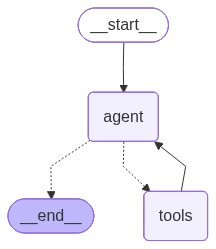

In [26]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

---

## Summary

### What Changed from Lesson 5

| Lesson 5 (Stateless Agent) | Lesson 6 (Persistent Agent) |
|:---|:---|
| No memory between invokes | Remembers every prior turn |
| Single conversation only | Many isolated conversations via `thread_id` |
| No way to inspect history | `get_state(config)` shows the full chart |
| Crash = data lost | Crash = pick up where you left off |

---

### The Key Insight

> We added **one argument** to `compile()` and **one config dict** to `invoke()`. That is the entire API. Yet it unlocks conversation memory, multi-user isolation, crash recovery, and the foundation for everything in the next lessons.

The checkpointer is the single biggest leverage point in LangGraph.

---

### API Reference

| Component | Purpose |
|:---|:---|
| `MemorySaver()` | In-RAM checkpointer (dev/test) |
| `workflow.compile(checkpointer=...)` | Attaches persistence to the graph |
| `config = {"configurable": {"thread_id": "..."}}` | Identifies which conversation to load |
| `app.invoke(input, config=config)` | Runs the graph on a specific thread |
| `app.get_state(config)` | Reads the saved State for a thread |

---

### Key Takeaways

> 1. A checkpointer saves State after every node automatically
> 2. `thread_id` separates conversations - same id continues, new id resets
> 3. The graph structure does not change; persistence is bolt-on
> 4. Production swaps `MemorySaver` for `SqliteSaver` or `PostgresSaver` - no code change
> 5. Everything in Lessons 7 and 8 builds on this foundation

---

**Next Lesson**: Now that the graph can pause and resume, we can put a human in the loop. Lesson 7 introduces `interrupt()` - a way to halt execution before a risky tool call and wait for a human to approve, edit, or reject the action.